In [1]:
import copy
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rc('font', family = 'serif', size = 13, weight = "bold")
plt.rc('xtick', labelsize = 10)
plt.rc('ytick', labelsize = 10)
plt.rc('axes', linewidth = 2)
plt.rc('lines', linewidth = 3)
plt.rc('figure', figsize = (6, 6))
plt.rc('legend', fontsize = 13)

cm = plt.cm.get_cmap('tab20')

/var/folders/3n/5_81jk8d0c793_12wzw3qzn00000gn/T/ipykernel_18298/880615570.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab20')


## ODE Model

- **Components (y)**: **G**(Genlet), **P**(RNA product), **Q:F**(quenched:flourophore complex, Q-quencher, F- flourophore), **P:Q**(RNA:quencher complex),**Q**(quencher), **F**(flourophore, a.k.a. signal)


- **Rates (p)**: $K_{p} = 0.02 (\frac{1}{s})$, $K_{dds} = 0.0003 (\frac{1}{s})$, $K_{slow} = \frac{1e^{5}}{1e^{9}} (\frac{1}{nM*s})$, $K_{fast} = \frac{1e^{6}}{1e^{9}} (\frac{1}{nM*s})$


- **ODEs**:

    $\frac{d[G]}{dt} = 0$

    $\frac{d[P]}{dt} = K_{p}[G] - K_{5bp}[P][Q:F]$

    $\frac{d[Q:F]}{dt} = -K_{5bp}[P][Q:F] + K_{6bp}[Q][F]$
    
    $\frac{d[P:F]}{dt} = K_{5bp}[P][Q:F] - K_{dds}[P:F]$
    
    $\frac{d[Q]}{dt} = K_{5bp}[P][Q:F] - K_{6bp}[Q][F]$
    
    $\frac{d[F]}{dt} = K_{dds}[P:F] - K_{6bp}[Q][F]$
    
    

In [4]:
def trans_deg_model(init_vals, params, t):
    """
    ode model for G1S1 transcription tracking with RNase H (dsRNA) degradation.
    """
    G0, P0, QF0, PF0, Q0, F0 = init_vals
    G, P, QF, PF, Q, F = [G0], [P0], [QF0], [PF0], [Q0], [F0]
    Kp, Kdds, K5bp, K6bp = params
    dt = t[1] - t[0]
    for _ in t[1:]:
        nextG = G[-1]
        
        nextP = P[-1] + (Kp*G[-1] - K5bp*P[-1]*QF[-1]) * dt
        if nextP < 0: nextP = 0
            
        nextQF = QF[-1] + (- K5bp*P[-1]*QF[-1] + K6bp*Q[-1]*F[-1])*dt
        if nextQF < 0: nextQF = 0
        if nextQF > QF0: nextQF = QF0
            
        nextPF = PF[-1] + (K5bp*P[-1]*QF[-1] - Kdds*PF[-1])*dt
        if nextPF < 0: nextPF = 0
        if nextPF > QF0: nextPF = QF0
            
        nextQ = Q[-1] + (K5bp*P[-1]*QF[-1] - K6bp*Q[-1]*F[-1])*dt
        if nextQ < 0: nextQ = 0
        if nextQ > QF0: nextQ = QF0
            
        nextF = F[-1] + (Kdds*PF[-1] - K6bp*Q[-1]*F[-1])*dt
        if nextF < 0: nextF = 0
        if nextF > QF0: nextF = QF0
            
        G.append(nextG); P.append(nextP); QF.append(nextQF); PF.append(nextPF); Q.append(nextQ);F.append(nextF)
        
    return np.stack([G, P, QF, PF, Q, F]).T

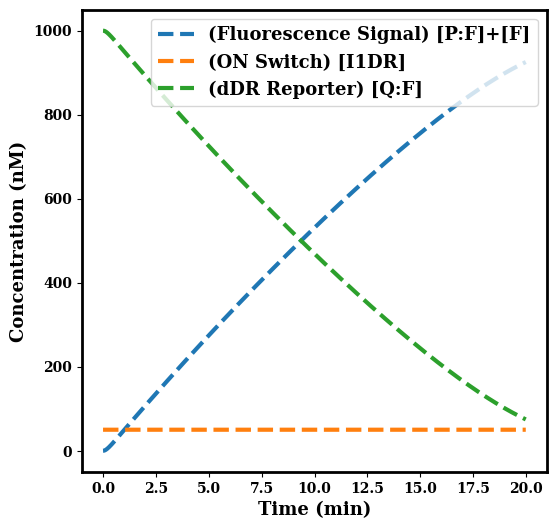

In [8]:
fig = plt.figure(figsize = (6, 6))

plt.subplot(1, 1, 1)
# G0 = 50nM, P0 = 0, QF = 1uM = 1000nM, PQ0 = 0; Q0 = 0, F0 = 0
init_vals = [50, 0, 1000, 0, 0, 0]

# Kp = 0.02 (1/s), Kdds = 0.0003 (1/s), K5bp = 1e5/1e9 = 1e-4(1/nM/s), K6bp = 1e6/1e9(1/nM/s)
params = [0.02, 0.0003, 1e5/1e9, 1e6/1e9]

# 1 hr = 60 min = 3600sec
timestamp = np.arange(20 * 60)

data = trans_deg_model(init_vals, params, timestamp)

plt.plot(timestamp / 60, (data[:, 3]+data[:, 5]), ls = '--', label = '(Fluorescence Signal) [P:F]+[F]')
plt.plot(timestamp / 60, data[:, 0], ls = '--', label = '(ON Switch) [I1DR]')
plt.plot(timestamp / 60, data[:, 2], ls = '--', label = '(dDR Reporter) [Q:F]')
# plt.plot(timestamp / 60, data[:, 4], ls = '--', label = 'Q')
plt.legend()
plt.xlabel("Time (min)", weight = 'bold')
plt.ylabel("Concentration (nM)", weight = 'bold')

plt.show()

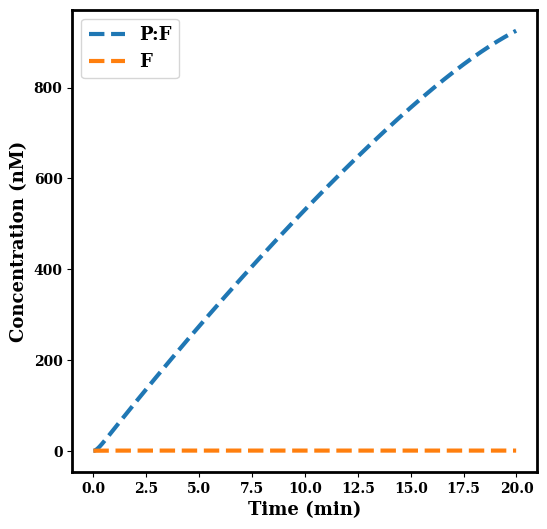

In [9]:
fig = plt.figure(figsize = (6, 6))

plt.subplot(1, 1, 1)
# G0 = 50nM, P0 = 0, QF = 1uM = 1000nM, PQ0 = 0; Q0 = 0, F0 = 0
init_vals = [50, 0, 1000, 0, 0, 0]

# Kp = 0.02 (1/s), Kdds = 0.0003 (1/s), K5bp = 1e5/1e9 = 1e-4(1/nM/s), K6bp = 1e6/1e9(1/nM/s)
params = [0.02, 0.0003, 1e5/1e9, 1e6/1e9]

# 1 hr = 60 min = 3600sec
timestamp = np.arange(20 * 60)

data = trans_deg_model(init_vals, params, timestamp)

plt.plot(timestamp / 60, data[:, 3], ls = '--', label = 'P:F')
plt.plot(timestamp / 60, data[:, 5], ls = '--', label = 'F')
plt.legend()
plt.xlabel("Time (min)", weight = 'bold')
plt.ylabel("Concentration (nM)", weight = 'bold')

plt.show()